In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from econml.dml import CausalForestDML
from sklearn.ensemble import RandomForestRegressor

In [2]:
df = pd.read_csv("/Users/ameypatil/Desktop/Tata Power/data/final.csv")

In [3]:
# Datetime handling
df["datetime"] = pd.to_datetime(df["datetime"])

df = df[df["datetime"].dt.year == 2025].copy()

# Feature
df['hour'] = df['datetime'].dt.hour

# Drop NaN
df = df.dropna()

In [4]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Summer"
    elif month in [6, 7, 8, 9]:
        return "Monsoon"
    else:
        return "Autumn"

df["Season"] = df["datetime"].dt.month.apply(get_season)
seasons = ["Winter", "Summer", "Monsoon", "Autumn"]

In [19]:
df.head()
print(df.shape)

(35040, 8)


CASE 1: Temp → Load


Processing: Winter
(8640,)
[-4.56221392 -4.65012046 -4.65012046 ... -1.24891683 -1.1296803
 -1.15148132]


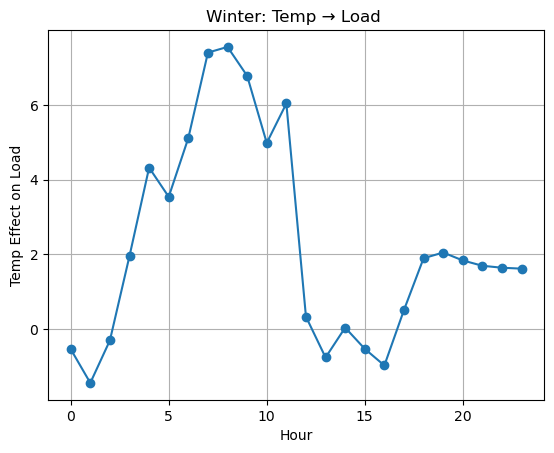

      hour         rh       temp    effect
0      0.0  78.066667  24.733333 -4.562214
1      0.0  78.133333  24.766667 -4.650120
2      0.0  78.133333  24.766667 -4.650120
3      0.0  78.333333  24.666667 -4.774507
4      1.0  78.633333  24.600000 -7.325089
...    ...        ...        ...       ...
8635  22.0  82.400000  20.900000 -1.076643
8636  23.0  81.800000  20.900000 -1.151481
8637  23.0  81.100000  20.800000 -1.248917
8638  23.0  82.800000  21.000000 -1.129680
8639  23.0  81.800000  21.100000 -1.151481

[8640 rows x 4 columns]
ATE Winter :  2.2817559890883308

Processing: Summer
(8832,)
[12.89640535 15.86172571 16.22733453 ...  8.59251594  7.01009337
  6.71039961]


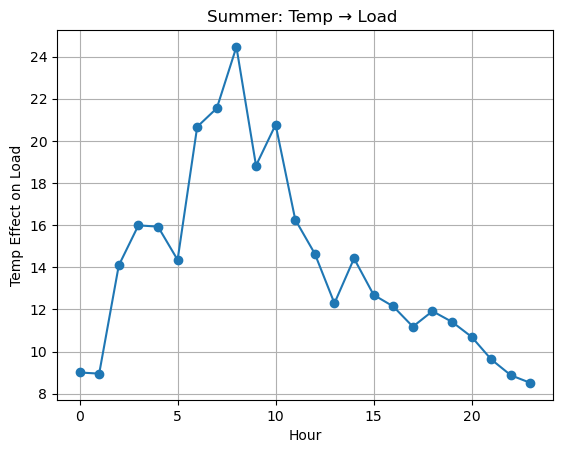

      hour      rh    temp     effect
0      0.0  51.900  26.850  12.896405
1      0.0  52.650  26.725  15.861726
2      0.0  52.725  26.475  16.227335
3      0.0  52.025  26.500  13.987389
4      1.0  52.325  26.375  16.867011
...    ...     ...     ...        ...
8827  22.0  88.025  27.525   9.362308
8828  23.0  88.575  27.475   9.191602
8829  23.0  89.400  27.450   8.592516
8830  23.0  89.725  27.525   7.010093
8831  23.0  89.825  27.675   6.710400

[8832 rows x 4 columns]
ATE Summer :  14.134696921381044

Processing: Monsoon
(11712,)
[9.13915103 7.0007202  6.88640875 ... 4.18462779 4.18462779 4.18462779]


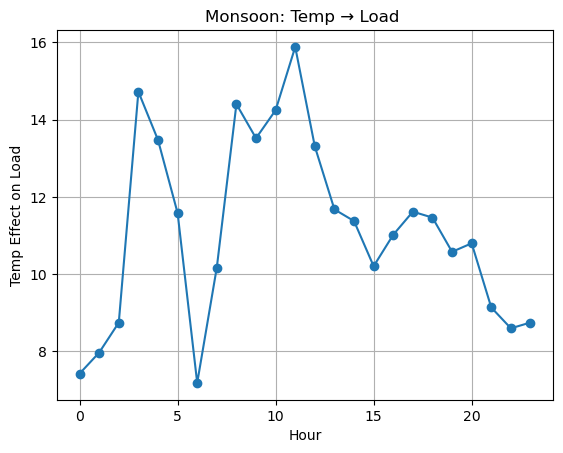

       hour      rh    temp    effect
0       0.0  90.475  27.750  9.139151
1       0.0  90.350  27.800  7.000720
2       0.0  90.125  27.900  6.886409
3       0.0  89.975  28.100  6.877559
4       1.0  89.725  28.275  4.717741
...     ...     ...     ...       ...
11707  22.0  99.500  24.300  3.541606
11708  23.0  99.500  24.400  4.184628
11709  23.0  99.500  24.400  4.184628
11710  23.0  99.500  24.400  4.184628
11711  23.0  99.500  24.350  4.184628

[11712 rows x 4 columns]
ATE Monsoon :  11.16008948312889

Processing: Autumn
(5856,)
[ 7.8973873  24.58941781 24.58941781 ...  9.18599036  8.37930417
  9.30852208]


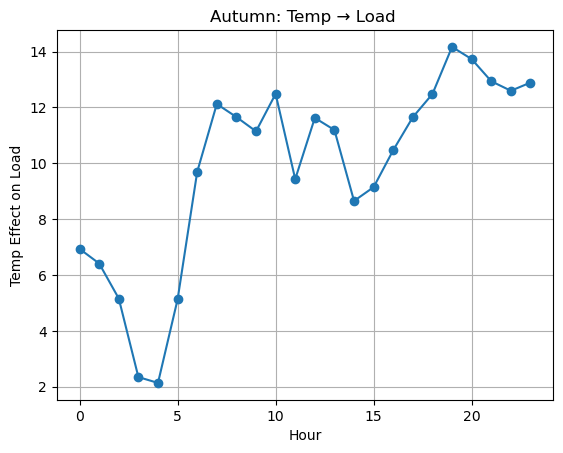

      hour    rh   temp     effect
0      0.0  99.5  24.35   7.897387
1      0.0  99.9  24.35  24.589418
2      0.0  99.9  24.35  24.589418
3      0.0  99.9  24.40  24.589418
4      1.0  99.9  24.40  22.058613
...    ...   ...    ...        ...
5851  22.0  64.4  21.80   8.315581
5852  23.0  63.5  21.75   9.398912
5853  23.0  63.7  21.60   9.185990
5854  23.0  64.4  21.50   8.379304
5855  23.0  67.1  21.45   9.308522

[5856 rows x 4 columns]
ATE Autumn :  9.840998848147523


In [18]:
for season in seasons:

    print("\nProcessing:", season)

    df_s = df[df["Season"] == season].dropna(subset=["wdLoad", "temp", "rh", "hour"])
    if len(df_s) < 50:
        continue

    Y = df_s["wdLoad"].values
    T = df_s["temp"].values
    X = df_s[["hour", "rh"]].values

    model = CausalForestDML(
        model_y=RandomForestRegressor(),
        model_t=RandomForestRegressor(),
        random_state=42
    )
    model.fit(Y, T, X=X)

    effects = model.effect(X)
    print(effects.shape)
    print(effects)
    df_effect = pd.DataFrame(X, columns=["hour", "rh"])
    df_effect["temp"] = T
    df_effect["effect"] = effects
    df.head()
    # 🔥 Group by hour
    hour_effect = df_effect.groupby("hour")["effect"].mean().reset_index()

    plt.figure()
    plt.plot(hour_effect["hour"], hour_effect["effect"], marker='o')

    plt.xlabel("Hour")
    plt.ylabel("Temp Effect on Load")
    plt.title(f"{season}: Temp → Load ")

    plt.grid()
    plt.show()
    print(df_effect)
    ate = np.mean(effects)
    print(f"ATE {season} : " , ate)

In [7]:
df.head(
)

,_id_x,datetime,wdLoad,_id_y,temp,rh,hour,Season
245494,67765a8757144a56a720e326,2025-01-01 00:00:00+00:00,276.186445,6776626d57144a56a720e3eb,24.733333,78.066667,0,Winter
245495,67765a8757144a56a720e327,2025-01-01 00:15:00+00:00,279.700694,6776626d57144a56a720e3ec,24.766667,78.133333,0,Winter
245496,67765a8757144a56a720e328,2025-01-01 00:30:00+00:00,283.051573,6776626d57144a56a720e3ed,24.766667,78.133333,0,Winter
245497,67765a8757144a56a720e329,2025-01-01 00:45:00+00:00,286.960382,6776626d57144a56a720e3ee,24.666667,78.333333,0,Winter
245498,67765a8757144a56a720e32a,2025-01-01 01:00:00+00:00,292.949629,6776626d57144a56a720e3ef,24.600000,78.633333,1,Winter


CASE 2: RH → Load

(8640,)
[-1.05505318 -1.00015723 -1.00015723 ...  0.16141943  0.24727704
  0.11894786]


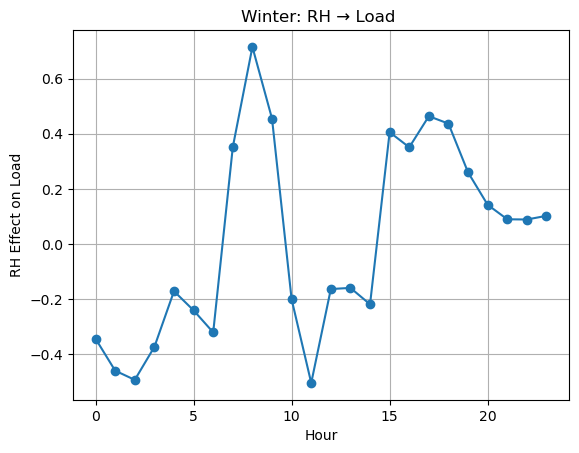

           temp  hour         rh    effect
0     24.733333   0.0  78.066667 -1.055053
1     24.766667   0.0  78.133333 -1.000157
2     24.766667   0.0  78.133333 -1.000157
3     24.666667   0.0  78.333333 -1.246484
4     24.600000   1.0  78.633333 -1.559436
...         ...   ...        ...       ...
8635  20.900000  22.0  82.400000  0.297786
8636  20.900000  23.0  81.800000  0.240955
8637  20.800000  23.0  81.100000  0.161419
8638  21.000000  23.0  82.800000  0.247277
8639  21.100000  23.0  81.800000  0.118948

[8640 rows x 4 columns]
ATE Winter :  0.008607277577072588
(8832,)
[0.72140978 0.55425027 0.29746192 ... 0.28371656 0.25967184 0.18905341]


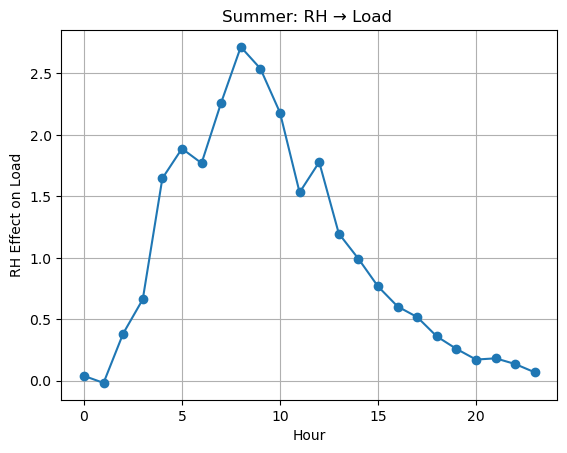

        temp  hour      rh    effect
0     26.850   0.0  51.900  0.721410
1     26.725   0.0  52.650  0.554250
2     26.475   0.0  52.725  0.297462
3     26.500   0.0  52.025  0.315384
4     26.375   1.0  52.325  0.322698
...      ...   ...     ...       ...
8827  27.525  22.0  88.025  0.269441
8828  27.475  23.0  88.575  0.255656
8829  27.450  23.0  89.400  0.283717
8830  27.525  23.0  89.725  0.259672
8831  27.675  23.0  89.825  0.189053

[8832 rows x 4 columns]
ATE Summer :  1.0264676532204655
(11712,)
[-0.23315671 -0.25728239 -0.17138442 ... -0.11422213 -0.11422213
 -0.10886479]


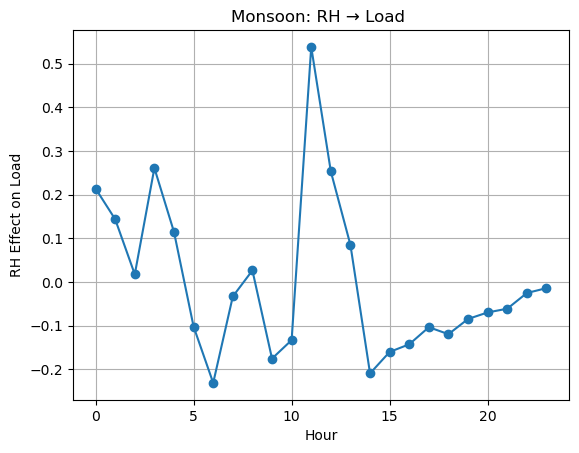

         temp  hour      rh    effect
0      27.750   0.0  90.475 -0.233157
1      27.800   0.0  90.350 -0.257282
2      27.900   0.0  90.125 -0.171384
3      28.100   0.0  89.975 -0.385203
4      28.275   1.0  89.725 -0.348171
...       ...   ...     ...       ...
11707  24.300  22.0  99.500 -0.286718
11708  24.400  23.0  99.500 -0.114222
11709  24.400  23.0  99.500 -0.114222
11710  24.400  23.0  99.500 -0.114222
11711  24.350  23.0  99.500 -0.108865

[11712 rows x 4 columns]
ATE Monsoon :  -0.000494391516841267
(5856,)
[-0.22192846 -0.22192846 -0.22192846 ...  0.62949503  0.5900693
  0.56640526]


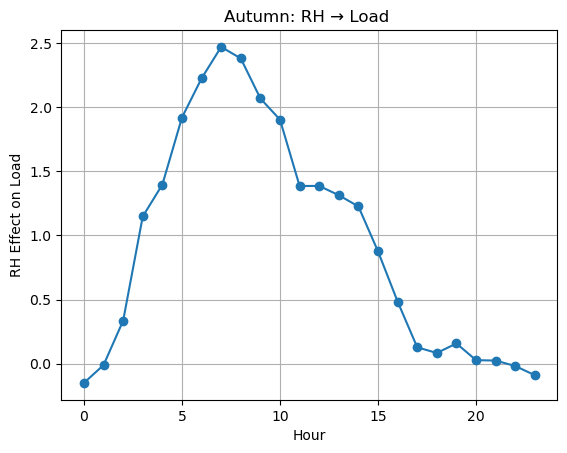

       temp  hour    rh    effect
0     24.35   0.0  99.5 -0.221928
1     24.35   0.0  99.9 -0.221928
2     24.35   0.0  99.9 -0.221928
3     24.40   0.0  99.9 -0.232627
4     24.40   1.0  99.9 -0.703976
...     ...   ...   ...       ...
5851  21.80  22.0  64.4  0.653356
5852  21.75  23.0  63.5  0.682165
5853  21.60  23.0  63.7  0.629495
5854  21.50  23.0  64.4  0.590069
5855  21.45  23.0  67.1  0.566405

[5856 rows x 4 columns]
ATE Autumn :  0.9442467511915993


In [13]:
for season in seasons:

    df_s = df[df["Season"] == season].dropna(subset=["wdLoad", "temp", "rh", "hour"])
    if len(df_s) < 50:
        continue

    Y = df_s["wdLoad"].values
    T = df_s["rh"].values
    X = df_s[["temp", "hour"]].values

    model = CausalForestDML(
        model_y=RandomForestRegressor(),
        model_t=RandomForestRegressor(),
        random_state=42
    )

    model.fit(Y, T, X=X)

    effects = model.effect(X)
    print(effects.shape)
    print(effects)
    df_effect = pd.DataFrame(X, columns=["temp", "hour"])
    df_effect["rh"] = T
    df_effect["effect"] = effects
    
    hour_effect = df_effect.groupby("hour")["effect"].mean().reset_index()

    plt.figure()
    plt.plot(hour_effect["hour"], hour_effect["effect"], marker='o')

    plt.xlabel("Hour")
    plt.ylabel("RH Effect on Load")
    plt.title(f"{season}: RH → Load ")

    plt.grid()
    plt.show()
    print(df_effect)
    ate = np.mean(effects)
    print(f"ATE {season} : " , ate)

CASE 3: Hour → Load


Processing: Winter
(8640,)
[-2.13520146 -2.18395729 -2.18395729 ... -1.93323596 -2.1057474
 -2.09319244]


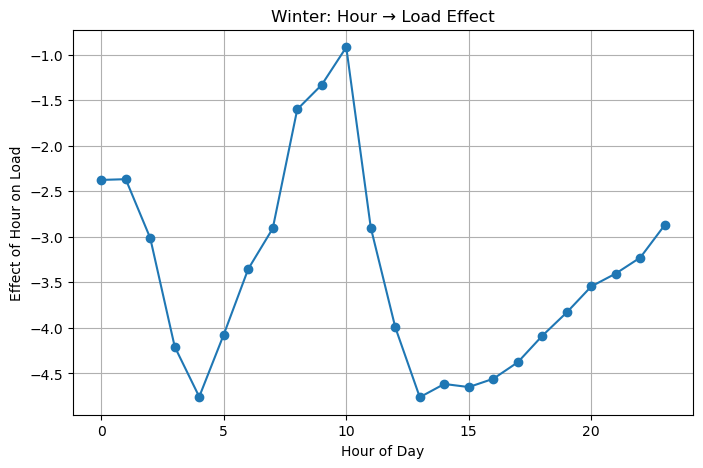

           temp         rh  hour    effect
0     24.733333  78.066667     0 -2.135201
1     24.766667  78.133333     0 -2.183957
2     24.766667  78.133333     0 -2.183957
3     24.666667  78.333333     0 -2.076403
4     24.600000  78.633333     1 -2.084163
...         ...        ...   ...       ...
8635  20.900000  82.400000    22 -2.003662
8636  20.900000  81.800000    23 -2.003662
8637  20.800000  81.100000    23 -1.933236
8638  21.000000  82.800000    23 -2.105747
8639  21.100000  81.800000    23 -2.093192

[8640 rows x 4 columns]
ATE Winter :  -3.405076040460124

Processing: Summer
(8832,)
[-1.55929056 -1.44270831 -1.48117591 ... -2.14711606 -2.22917969
 -2.40099352]


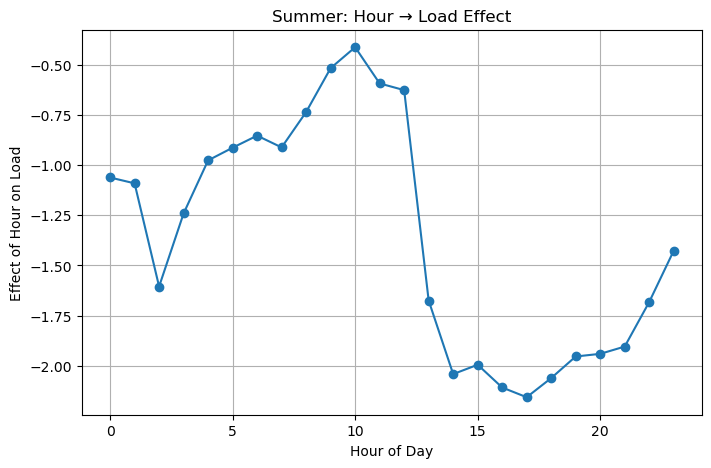

        temp      rh  hour    effect
0     26.850  51.900     0 -1.559291
1     26.725  52.650     0 -1.442708
2     26.475  52.725     0 -1.481176
3     26.500  52.025     0 -1.449601
4     26.375  52.325     1 -1.487477
...      ...     ...   ...       ...
8827  27.525  88.025    22 -1.892279
8828  27.475  88.575    23 -1.832871
8829  27.450  89.400    23 -2.147116
8830  27.525  89.725    23 -2.229180
8831  27.675  89.825    23 -2.400994

[8832 rows x 4 columns]
ATE Summer :  -1.3537598080193372

Processing: Monsoon
(11712,)
[-2.84423855 -2.79038558 -2.63297074 ... -1.98333792 -1.98333792
 -2.10696853]


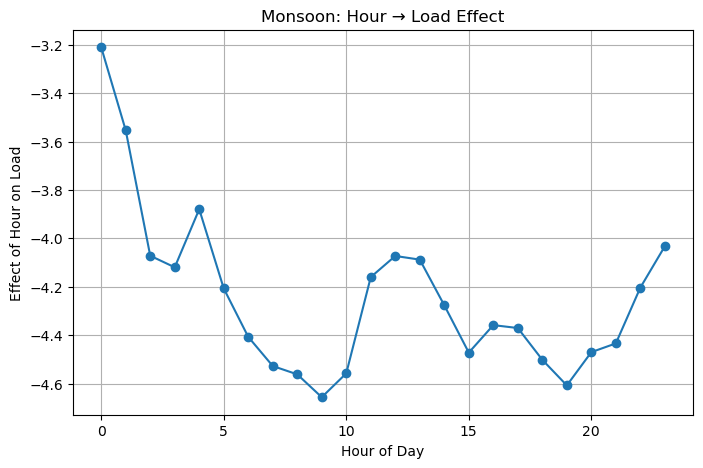

         temp      rh  hour    effect
0      27.750  90.475     0 -2.844239
1      27.800  90.350     0 -2.790386
2      27.900  90.125     0 -2.632971
3      28.100  89.975     0 -2.840420
4      28.275  89.725     1 -1.328672
...       ...     ...   ...       ...
11707  24.300  99.500    22 -2.042181
11708  24.400  99.500    23 -1.983338
11709  24.400  99.500    23 -1.983338
11710  24.400  99.500    23 -1.983338
11711  24.350  99.500    23 -2.106969

[11712 rows x 4 columns]
ATE Monsoon :  -4.241776164633587

Processing: Autumn
(5856,)
[-1.15235258 -1.03216705 -1.03216705 ... -1.98499509 -1.9226469
 -2.09324135]


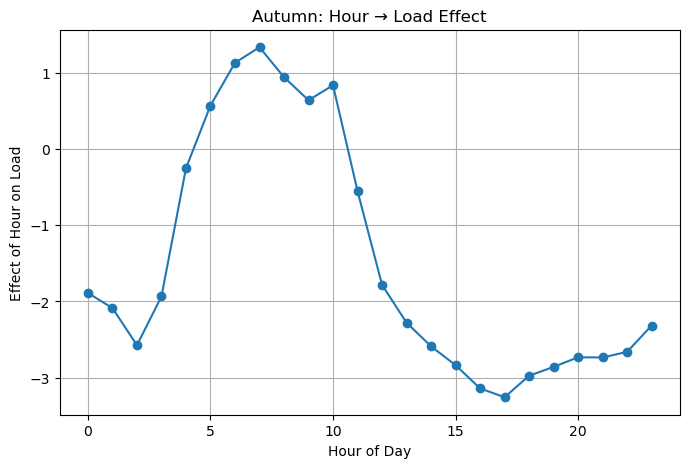

       temp    rh  hour    effect
0     24.35  99.5     0 -1.152353
1     24.35  99.9     0 -1.032167
2     24.35  99.9     0 -1.032167
3     24.40  99.9     0 -1.068829
4     24.40  99.9     1 -1.068829
...     ...   ...   ...       ...
5851  21.80  64.4    22 -2.361686
5852  21.75  63.5    23 -2.274794
5853  21.60  63.7    23 -1.984995
5854  21.50  64.4    23 -1.922647
5855  21.45  67.1    23 -2.093241

[5856 rows x 4 columns]
ATE Autumn :  -1.500009907101201


In [9]:
import matplotlib.pyplot as plt

seasons = ["Winter", "Summer", "Monsoon", "Autumn"]

for season in seasons:

    print("\nProcessing:", season)

    df_s = df[df["Season"] == season].copy()
    df_s = df_s.dropna(subset=["wdLoad", "temp", "rh", "hour"])

    if len(df_s) < 50:
        print("Skipped")
        continue

    # -------------------------------
    # 🔹 Model training (Hour → Load)
    # -------------------------------
    Y = df_s["wdLoad"].values
    T = df_s["hour"].values          # Treatment = hour
    X = df_s[["temp", "rh"]].values  # Controls

    model = CausalForestDML(
        model_y=RandomForestRegressor(),
        model_t=RandomForestRegressor(),
        n_estimators=100,
        min_samples_leaf=10,
        random_state=42
    )

    model.fit(Y, T, X=X)

    # -------------------------------
    # 🔹 Get Individual Effects
    # -------------------------------
    effects = model.effect(X)
    print(effects.shape)
    print(effects)
    df_effect = pd.DataFrame(X, columns=["temp", "rh"])
    df_effect["hour"] = T
    df_effect["effect"] = effects

    # -------------------------------
    # 🔹 Group by hour (KEY STEP)
    # -------------------------------
    hour_effect = df_effect.groupby("hour")["effect"].mean().reset_index()

    # -------------------------------
    # 🔹 Plot
    # -------------------------------
    plt.figure(figsize=(8,5))
    plt.plot(hour_effect["hour"], hour_effect["effect"], marker='o')

    plt.xlabel("Hour of Day")
    plt.ylabel("Effect of Hour on Load")
    plt.title(f"{season}: Hour → Load Effect")

    plt.grid()
    plt.show()
    print(df_effect)
    ate = np.mean(effects)
    print(f"ATE {season} : " , ate)

CASE 4: Temp + RH → Load

(8640, 2)
[[-0.79977975 -0.44365282]
 [-0.79977975 -0.44365282]
 [-0.79977975 -0.44365282]
 ...
 [ 0.45856913 -0.24313082]
 [ 0.45856913 -0.24313082]
 [ 0.45856913 -0.24313082]]


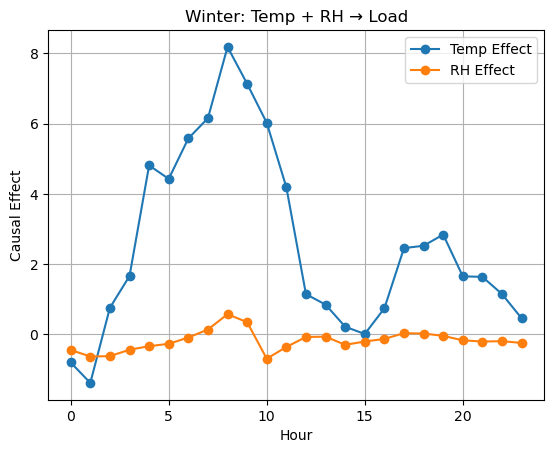

      hour       temp         rh  effect_temp  effect_rh
0        0  24.733333  78.066667    -0.799780  -0.443653
1        0  24.766667  78.133333    -0.799780  -0.443653
2        0  24.766667  78.133333    -0.799780  -0.443653
3        0  24.666667  78.333333    -0.799780  -0.443653
4        1  24.600000  78.633333    -1.382135  -0.629708
...    ...        ...        ...          ...        ...
8635    22  20.900000  82.400000     1.148762  -0.192897
8636    23  20.900000  81.800000     0.458569  -0.243131
8637    23  20.800000  81.100000     0.458569  -0.243131
8638    23  21.000000  82.800000     0.458569  -0.243131
8639    23  21.100000  81.800000     0.458569  -0.243131

[8640 rows x 5 columns]
ATE (Temperature) Winter: 2.601825642195608
ATE (Humidity) Winter: -0.18217548683950868
(8832, 2)
[[ 7.52661317 -0.05934052]
 [ 7.52661317 -0.05934052]
 [ 7.52661317 -0.05934052]
 ...
 [ 8.56772068  0.01453608]
 [ 8.56772068  0.01453608]
 [ 8.56772068  0.01453608]]


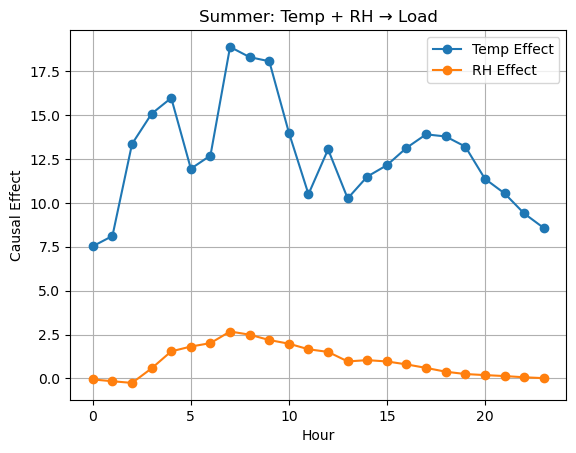

      hour    temp      rh  effect_temp  effect_rh
0        0  26.850  51.900     7.526613  -0.059341
1        0  26.725  52.650     7.526613  -0.059341
2        0  26.475  52.725     7.526613  -0.059341
3        0  26.500  52.025     7.526613  -0.059341
4        1  26.375  52.325     8.110762  -0.160827
...    ...     ...     ...          ...        ...
8827    22  27.525  88.025     9.393766   0.064570
8828    23  27.475  88.575     8.567721   0.014536
8829    23  27.450  89.400     8.567721   0.014536
8830    23  27.525  89.725     8.567721   0.014536
8831    23  27.675  89.825     8.567721   0.014536

[8832 rows x 5 columns]
ATE (Temperature) Summer: 12.716229675441003
ATE (Humidity) Summer: 0.9729483067518458
(11712, 2)
[[5.81755429 0.07989407]
 [5.81755429 0.07989407]
 [5.81755429 0.07989407]
 ...
 [7.40526342 0.12517923]
 [7.40526342 0.12517923]
 [7.40526342 0.12517923]]


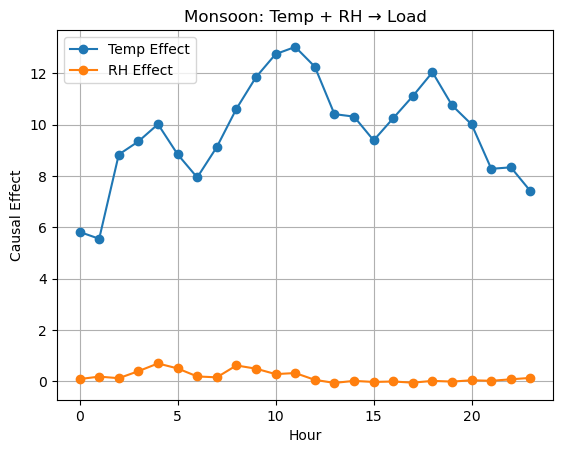

       hour    temp      rh  effect_temp  effect_rh
0         0  27.750  90.475     5.817554   0.079894
1         0  27.800  90.350     5.817554   0.079894
2         0  27.900  90.125     5.817554   0.079894
3         0  28.100  89.975     5.817554   0.079894
4         1  28.275  89.725     5.549747   0.174672
...     ...     ...     ...          ...        ...
11707    22  24.300  99.500     8.335475   0.070347
11708    23  24.400  99.500     7.405263   0.125179
11709    23  24.400  99.500     7.405263   0.125179
11710    23  24.400  99.500     7.405263   0.125179
11711    23  24.350  99.500     7.405263   0.125179

[11712 rows x 5 columns]
ATE (Temperature) Monsoon: 9.761521174620857
ATE (Humidity) Monsoon: 0.16902167537540944
(5856, 2)
[[ 9.53365137 -0.31908718]
 [ 9.53365137 -0.31908718]
 [ 9.53365137 -0.31908718]
 ...
 [10.83229748 -0.2352268 ]
 [10.83229748 -0.2352268 ]
 [10.83229748 -0.2352268 ]]


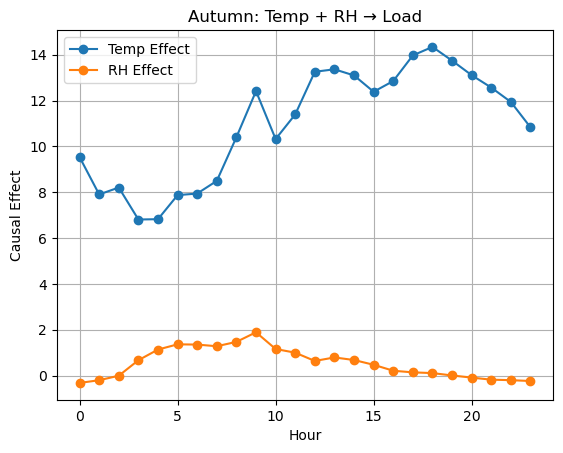

      hour   temp    rh  effect_temp  effect_rh
0        0  24.35  99.5     9.533651  -0.319087
1        0  24.35  99.9     9.533651  -0.319087
2        0  24.35  99.9     9.533651  -0.319087
3        0  24.40  99.9     9.533651  -0.319087
4        1  24.40  99.9     7.904152  -0.200491
...    ...    ...   ...          ...        ...
5851    22  21.80  64.4    11.938249  -0.198993
5852    23  21.75  63.5    10.832297  -0.235227
5853    23  21.60  63.7    10.832297  -0.235227
5854    23  21.50  64.4    10.832297  -0.235227
5855    23  21.45  67.1    10.832297  -0.235227

[5856 rows x 5 columns]
ATE (Temperature) Autumn: 10.981723132325389
ATE (Humidity) Autumn: 0.5483906902946009


In [12]:
for season in seasons:

    df_s = df[df["Season"] == season].dropna(subset=["wdLoad", "temp", "rh", "hour"])
    if len(df_s) < 50:
        continue

    Y = df_s["wdLoad"].values
    T = df_s[["temp", "rh"]].values
    X = df_s[["hour"]].values

    model = CausalForestDML(
        model_y=RandomForestRegressor(),
        model_t=RandomForestRegressor(),
        random_state=42
    )

    model.fit(Y, T, X=X)

    effects = model.const_marginal_effect(X)
    print(effects.shape)
    print(effects)
    df_effect = pd.DataFrame(X, columns=["hour"])
    df_effect["temp"] = T[:, 0]
    df_effect["rh"] = T[:, 1]

    df_effect["effect_temp"] = effects[:, 0]
    df_effect["effect_rh"] = effects[:, 1]

    hour_effect = df_effect.groupby("hour")[["effect_temp", "effect_rh"]].mean().reset_index()

    plt.figure()

    plt.plot(hour_effect["hour"], hour_effect["effect_temp"], marker='o', label="Temp Effect")
    plt.plot(hour_effect["hour"], hour_effect["effect_rh"], marker='o', label="RH Effect")

    plt.xlabel("Hour")
    plt.ylabel("Causal Effect")
    plt.title(f"{season}: Temp + RH → Load")

    plt.legend()
    plt.grid()
    plt.show()
    print(df_effect)
    ate_temp = np.mean(effects[:,0])
    ate_rh = np.mean(effects[:,1])

    print(f"ATE (Temperature) {season}:", ate_temp)
    print(f"ATE (Humidity) {season}:", ate_rh)